
# Linear Regression

## Mục tiêu bài học

Trong notebook này, chúng ta sẽ học:

1. Linear Regression là gì
2. Công thức của Linear Regression
3. Model học cái gì
4. Loss Function dùng trong Linear Regression
5. Demo dự đoán điểm thi theo số giờ học
6. Đánh giá model bằng MSE, RMSE, MAE, R²
7. Dự đoán điểm thi cho dữ liệu mới

---

## 1. Linear Regression là gì?

**Linear Regression** là một mô hình Machine Learning dùng để dự đoán một giá trị số liên tục.

Ví dụ:

- Dự đoán giá nhà
- Dự đoán lương
- Dự đoán doanh thu
- Dự đoán điểm thi

Linear Regression thuộc nhóm:

```text
Supervised Learning
→ Regression Problem
```

Nghĩa là:

- Có dữ liệu đầu vào `X`
- Có nhãn / kết quả thật `y`
- Model học từ dữ liệu cũ để dự đoán dữ liệu mới



## 2. Ý tưởng chính

Linear Regression giả định rằng:

```text
Y có quan hệ tuyến tính với X
```

Ví dụ:

```text
Điểm thi = b0 + b1 × số giờ học
```

Công thức tổng quát:

$$
y = b_0 + b_1x
$$

Trong đó:

| Ký hiệu | Ý nghĩa |
|---|---|
| `y` | Giá trị cần dự đoán |
| `x` | Feature / biến đầu vào |
| `b0` | Intercept / bias |
| `b1` | Coefficient / weight / slope |

Ví dụ:

$$
Score = 40 + 5 \times Hours
$$

Nếu học 6 giờ:

$$
Score = 40 + 5 \times 6 = 70
$$



## 3. Model học cái gì?

Model cần học ra 2 giá trị chính:

```text
b0 = intercept
b1 = coefficient
```

Ví dụ model học được:

$$
Score = 35 + 8 \times Hours
$$

Ý nghĩa:

- Nếu số giờ học tăng thêm 1 giờ, điểm dự đoán tăng khoảng 8 điểm
- `35` là điểm nền khi số giờ học bằng 0
- `8` là mức độ ảnh hưởng của số giờ học lên điểm thi

Mục tiêu của model là tìm một đường thẳng phù hợp nhất với dữ liệu.



## 4. Loss Function trong Linear Regression

Sau khi model dự đoán, ta cần đo xem model sai bao nhiêu.

Ví dụ:

```text
Điểm thật: 80
Điểm dự đoán: 75
Sai số: 80 - 75 = 5
```

Linear Regression thường dùng **MSE - Mean Squared Error**:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Trong đó:

| Ký hiệu | Ý nghĩa |
|---|---|
| `y_i` | Giá trị thật |
| `ŷ_i` | Giá trị model dự đoán |
| `n` | Số lượng dữ liệu |

Ý nghĩa:

```text
MSE càng nhỏ → model dự đoán càng tốt.
MSE càng lớn → model dự đoán càng sai.
```



## 5. Quá trình training Linear Regression

Quá trình training gồm:

```text
1. Có dữ liệu X và y
2. Model dự đoán y_pred
3. Tính loss
4. Điều chỉnh b0 và b1
5. Lặp lại để loss nhỏ nhất
```

Trong thư viện `sklearn`, ta không cần tự viết quá trình tối ưu.  
Ta chỉ cần dùng:

```python
model.fit(X_train, y_train)
```

Model sẽ tự tìm ra đường thẳng tốt nhất.



# Demo: Dự đoán điểm thi theo số giờ học

Ta sẽ tạo một dataset nhỏ gồm:

- `Hours`: số giờ học
- `Score`: điểm thi

Mục tiêu:

```text
Dùng số giờ học để dự đoán điểm thi.
```


In [1]:

# Import thư viện cần thiết

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:

# Tạo dataset mẫu
df = pd.read_csv("../data/student_exam_scores/student_exam_scores.csv")



## 6. Xem nhanh dữ liệu

Ta sẽ kiểm tra:

- 5 dòng đầu
- Thông tin dữ liệu
- Thống kê cơ bản


In [3]:

df.head()


,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [4]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [5]:

df.describe()


,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000



## 7. Vẽ dữ liệu

Trước khi train model, ta nên vẽ dữ liệu để xem quan hệ giữa `Hours` và `Score`.

Nếu các điểm dữ liệu có xu hướng tăng theo đường thẳng, Linear Regression có thể phù hợp.


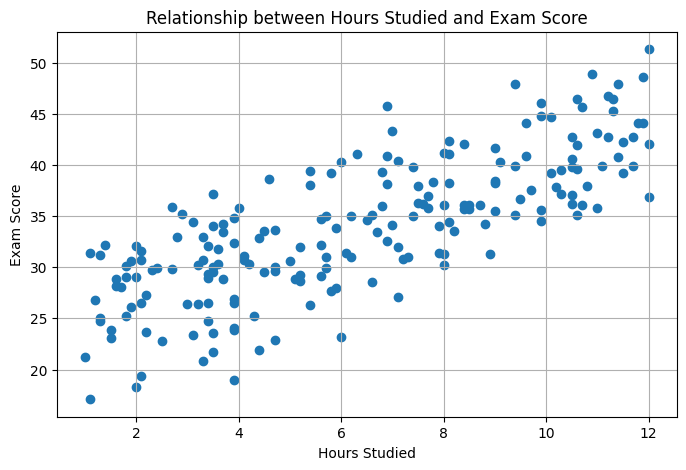

In [6]:

plt.figure(figsize=(8, 5))
plt.scatter(df["hours_studied"], df["exam_score"])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Relationship between Hours Studied and Exam Score")
plt.grid(True)
plt.show()



## 8. Chia dữ liệu thành X và y

Trong Machine Learning:

```text
X = feature / input
y = target / output
```

Ở bài này:

```text
X = Hours
y = Score
```


In [7]:

X = df[["hours_studied"]]
y = df["exam_score"]

print("X:")
display(X.head())

print("y:")
display(y.head())


X:


,hours_studied
0,8.0
1,1.3
2,4.0
3,3.5
4,9.1


y:


0    30.2
1    25.0
2    35.8
3    34.0
4    40.3
Name: exam_score, dtype: float64


## 9. Chia train/test

Ta chia dữ liệu thành:

- `train set`: dùng để model học
- `test set`: dùng để kiểm tra model

Ví dụ:

```text
80% train
20% test
```


In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Số dòng X_train:", len(X_train))
print("Số dòng X_test:", len(X_test))


Số dòng X_train: 160
Số dòng X_test: 40



## 10. Train Linear Regression model


In [9]:

model = LinearRegression()

model.fit(X_train, y_train)

print("Train xong model!")


Train xong model!



## 11. Xem intercept và coefficient

Sau khi train, model học được:

```text
Score = intercept + coefficient × Hours
```


In [10]:

intercept = model.intercept_
coefficient = model.coef_[0]

print("Intercept:", intercept)
print("Coefficient:", coefficient)

print(f"Công thức model học được:")
print(f"Score = {intercept:.2f} + {coefficient:.2f} × Hours")


Intercept: 23.784028523024055
Coefficient: 1.6146305496352773
Công thức model học được:
Score = 23.78 + 1.61 × Hours



## 12. Dự đoán trên test set


In [11]:

y_pred = model.predict(X_test)

result = pd.DataFrame({
    "Hours": X_test["hours_studied"],
    "Actual Score": y_test,
    "Predicted Score": y_pred
})

result


,Hours,Actual Score,Predicted Score
95,5.2,28.7,32.180107
15,7.0,34.1,35.086442
30,9.9,34.5,39.768871
158,3.5,29.5,29.435235
128,10.7,36.1,41.060575
115,10.6,46.4,40.899112
69,3.9,23.9,30.081088
170,11.3,45.3,42.029354
174,9.9,44.8,39.768871
45,3.6,31.8,29.596699



## 13. Đánh giá model

Ta dùng các chỉ số:

| Metric | Ý nghĩa |
|---|---|
| MAE | Sai số tuyệt đối trung bình |
| MSE | Sai số bình phương trung bình |
| RMSE | Căn bậc hai của MSE |
| R² | Model giải thích được bao nhiêu phần trăm biến động của y |

Cách hiểu nhanh:

```text
MAE, MSE, RMSE càng nhỏ càng tốt.
R² càng gần 1 càng tốt.
```


In [12]:

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 3.8271943573079588
MSE: 19.162629757666952
RMSE: 4.377514107078006
R²: 0.6389185293099702



## 14. Vẽ đường Linear Regression

Ta sẽ vẽ:

- Các điểm dữ liệu thật
- Đường thẳng model học được


c:\Users\ASUS\Documents\PROJECT\intro_to_AI\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


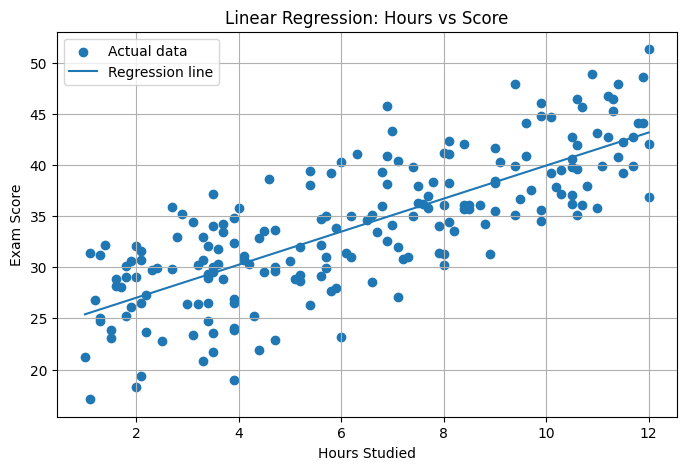

In [14]:

plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Actual data")

# Tạo đường dự đoán
x_line = np.linspace(X["hours_studied"].min(), X["hours_studied"].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.plot(x_line, y_line, label="Regression line")

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression: Hours vs Score")
plt.legend()
plt.grid(True)
plt.show()



## 15. Dự đoán điểm thi cho dữ liệu mới

Bây giờ ta thử dự đoán:

```text
Nếu học 7.5 giờ thì được bao nhiêu điểm?
Nếu học 11 giờ thì được bao nhiêu điểm?
```


In [15]:

new_hours = pd.DataFrame({
    "hours_studied": [7.5, 11]
})

predicted_scores = model.predict(new_hours)

prediction_result = pd.DataFrame({
    "Hours": new_hours["hours_studied"],
    "Predicted Score": predicted_scores
})

prediction_result


,Hours,Predicted Score
0,7.5,35.893758
1,11.0,41.544965



## 16. Tự nhập số giờ học để dự đoán

Bạn có thể đổi giá trị trong biến `my_hours`.


In [17]:

my_hours = 30

my_data = pd.DataFrame({
    "hours_studied": [my_hours]
})

my_prediction = model.predict(my_data)

print(f"Nếu học {my_hours} giờ, điểm dự đoán là: {my_prediction[0]:.2f}")


Nếu học 30 giờ, điểm dự đoán là: 72.22



# 17. Nếu muốn dùng dataset thật từ Kaggle

Một dataset thường dùng là **Student Scores Dataset**.

Bạn có thể thử tải bằng `kagglehub`.

Lưu ý:

- Cần cài `kagglehub`
- Một số dataset Kaggle có thể yêu cầu tài khoản Kaggle hoặc token
- Nếu tải được, bạn thay đường dẫn file CSV vào `pd.read_csv(...)`

```python
!pip install kagglehub
```


In [ ]:

# Ví dụ tải dataset bằng kagglehub
# Nếu bạn chạy được trên máy cá nhân hoặc Kaggle Notebook, hãy bỏ comment đoạn dưới.

# import kagglehub
# import os
# import pandas as pd

# path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
# print("Path to dataset files:", path)

# print(os.listdir(path))

# Sau đó đọc file CSV, ví dụ:
# df_real = pd.read_csv(os.path.join(path, "StudentsPerformance.csv"))
# df_real.head()



## 18. Lưu ý khi dùng dataset thật

Dataset `StudentsPerformance.csv` thường có các cột như:

- gender
- race/ethnicity
- parental level of education
- lunch
- test preparation course
- math score
- reading score
- writing score

Với Linear Regression, ta có thể làm ví dụ:

```text
Dùng reading score để dự đoán writing score
```

hoặc:

```text
Dùng math score để dự đoán writing score
```

Ví dụ:

```python
X = df_real[["reading score"]]
y = df_real["writing score"]
```

Sau đó các bước train model giống như demo ở trên.


In [ ]:

# Demo template nếu đã có df_real

# X = df_real[["reading score"]]
# y = df_real["writing score"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# model_real = LinearRegression()
# model_real.fit(X_train, y_train)

# y_pred = model_real.predict(X_test)

# print("Intercept:", model_real.intercept_)
# print("Coefficient:", model_real.coef_[0])
# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("MSE:", mean_squared_error(y_test, y_pred))
# print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
# print("R²:", r2_score(y_test, y_pred))



# 19. Tóm tắt

Linear Regression là mô hình dùng để dự đoán giá trị số liên tục.

Công thức:

$$
y = b_0 + b_1x
$$

Trong đó:

- `b0`: intercept
- `b1`: coefficient
- `x`: input
- `y`: output cần dự đoán

Mục tiêu:

```text
Tìm đường thẳng tốt nhất sao cho sai số nhỏ nhất.
```

Loss thường dùng:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Câu nhớ nhanh:

```text
Linear Regression tìm đường thẳng tốt nhất để dự đoán một giá trị số.
```
